In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("cleaned_superstore.csv")

In [ ]:
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07,CA-2011-130813,...,19,Consumer,2011-01-09,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21,CA-2011-148614,...,19,Consumer,2011-01-26,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05,CA-2011-118962,...,21,Consumer,2011-08-09,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05,CA-2011-118962,...,111,Consumer,2011-08-09,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29,CA-2011-146969,...,6,Consumer,2011-10-03,Standard Class,1.32,California,Paper,2011,North America,40


In [6]:
df.isnull().sum()

Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [5]:
#data type
df['Order.Date'] = pd.to_datetime(df['Order.Date'])
df['Ship.Date'] = pd.to_datetime(df['Ship.Date'])

In [15]:
df.columns

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', '记录数', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID',
       'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

In [14]:
#Fix Data Inconsistencies
df.Category.unique()


array(['Office Supplies', 'Technology', 'Furniture'], dtype=object)

In [10]:
df["Sub.Category"].unique()

array(['Paper', 'Art', 'Storage', 'Appliances', 'Supplies', 'Envelopes',
       'Fasteners', 'Labels', 'Binders', 'Accessories', 'Phones',
       'Copiers', 'Machines', 'Tables', 'Bookcases', 'Chairs',
       'Furnishings'], dtype=object)

In [16]:
cat_cols = ["Category", "Sub.Category", "Ship.Mode", "Market", "Region", "Segment"]

for col in cat_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


Unique values in Category:
['Office Supplies' 'Technology' 'Furniture']

Unique values in Sub.Category:
['Paper' 'Art' 'Storage' 'Appliances' 'Supplies' 'Envelopes' 'Fasteners'
 'Labels' 'Binders' 'Accessories' 'Phones' 'Copiers' 'Machines' 'Tables'
 'Bookcases' 'Chairs' 'Furnishings']

Unique values in Ship.Mode:
['Second Class' 'Standard Class' 'Same Day' 'First Class']

Unique values in Market:
['US' 'EU' 'LATAM' 'Africa' 'APAC' 'EMEA' 'Canada']

Unique values in Region:
['West' 'East' 'South' 'Central' 'Africa' 'Central Asia' 'North Asia'
 'Caribbean' 'North' 'EMEA' 'Oceania' 'Southeast Asia' 'Canada']

Unique values in Segment:
['Consumer' 'Home Office' 'Corporate']


In [17]:
print(df[df["Sales"] < 0])
print(df[df["Quantity"] < 0])
print(df[df["Shipping.Cost"] < 0])

Empty DataFrame
Columns: [Category, City, Country, Customer.ID, Customer.Name, Discount, Market, 记录数, Order.Date, Order.ID, Order.Priority, Product.ID, Product.Name, Profit, Quantity, Region, Row.ID, Sales, Segment, Ship.Date, Ship.Mode, Shipping.Cost, State, Sub.Category, Year, Market2, weeknum]
Index: []

[0 rows x 27 columns]
Empty DataFrame
Columns: [Category, City, Country, Customer.ID, Customer.Name, Discount, Market, 记录数, Order.Date, Order.ID, Order.Priority, Product.ID, Product.Name, Profit, Quantity, Region, Row.ID, Sales, Segment, Ship.Date, Ship.Mode, Shipping.Cost, State, Sub.Category, Year, Market2, weeknum]
Index: []

[0 rows x 27 columns]
Empty DataFrame
Columns: [Category, City, Country, Customer.ID, Customer.Name, Discount, Market, 记录数, Order.Date, Order.ID, Order.Priority, Product.ID, Product.Name, Profit, Quantity, Region, Row.ID, Sales, Segment, Ship.Date, Ship.Mode, Shipping.Cost, State, Sub.Category, Year, Market2, weeknum]
Index: []

[0 rows x 27 columns]


In [18]:
#Handling Outliers
df[["Sales", "Quantity", "Profit", "Shipping.Cost"]].describe()


,Sales,Quantity,Profit,Shipping.Cost
count,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.498440,3.476545,28.610982,26.375818
std,487.567175,2.278766,174.340972,57.296810
min,0.000000,1.000000,-6599.978000,0.002000
25%,31.000000,2.000000,0.000000,2.610000
50%,85.000000,3.000000,9.240000,7.790000
75%,251.000000,5.000000,36.810000,24.450000
max,22638.000000,14.000000,8399.976000,933.570000


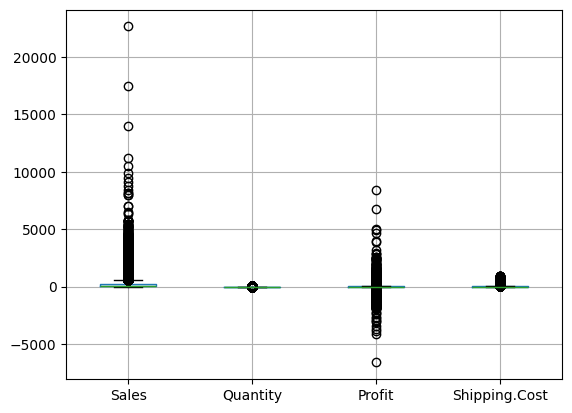

In [19]:
import matplotlib.pyplot as plt

df[["Sales", "Quantity", "Profit", "Shipping.Cost"]].boxplot()
plt.show()

In [6]:
#Create New Columns
df["Month"] = df["Order.Date"].dt.month
df["Day"] = df["Order.Date"].dt.day
df["Day_Name"] = df["Order.Date"].dt.day_name()

In [8]:
df.head(3)

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum,Month,Day,Day_Name
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07,CA-2011-130813,...,Second Class,4.37,California,Paper,2011,North America,2,1,7,Friday
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21,CA-2011-148614,...,Standard Class,0.94,California,Paper,2011,North America,4,1,21,Friday
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05,CA-2011-118962,...,Standard Class,1.81,California,Paper,2011,North America,32,8,5,Friday


In [9]:
df[["Order.Date", "Month", "Day", "Day_Name"]].head()

,Order.Date,Month,Day,Day_Name
0,2011-01-07,1,7,Friday
1,2011-01-21,1,21,Friday
2,2011-08-05,8,5,Friday
3,2011-08-05,8,5,Friday
4,2011-09-29,9,29,Thursday


In [10]:
df.to_csv("final_cleaned_superstore.csv", index=False)

week 2
sub task 1

Which month had highest sales?
Which month had lowest sales?
Are there seasonal spikes?
Are some months consistently weak?
Which year had highest sales?
Is business growing every year?
Any drop in sales?
Visualizations

You need graphs like:

Monthly sales line chart
Yearly sales bar chart/line chart

In [2]:
#Load final cleaned dataset

import pandas as pd

df = pd.read_csv("final_cleaned_superstore.csv")
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum,Month,Day,Day_Name
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07,CA-2011-130813,...,Second Class,4.37,California,Paper,2011,North America,2,1,7,Friday
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21,CA-2011-148614,...,Standard Class,0.94,California,Paper,2011,North America,4,1,21,Friday
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05,CA-2011-118962,...,Standard Class,1.81,California,Paper,2011,North America,32,8,5,Friday
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05,CA-2011-118962,...,Standard Class,4.59,California,Paper,2011,North America,32,8,5,Friday
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29,CA-2011-146969,...,Standard Class,1.32,California,Paper,2011,North America,40,9,29,Thursday


In [3]:
df["Order.Date"]= pd.to_datetime(df["Order.Date"])

In [6]:
#Aggregate Sales by Month
df["year"]= df["Order.Date"].dt.year
df["month"] = df["Order.Date"].dt.month 

monthly_sales = df.groupby(["year","month"])["Sales"].sum()
monthly_sales



year  month
2011  1         98902
      2         91152
      3        145726
      4        116927
      5        146762
      6        215214
      7        115518
      8        207570
      9        290230
      10       199070
      11       298499
      12       333941
2012  1        135775
      2        100521
      3        163092
      4        161060
      5        208370
      6        256181
      7        145247
      8        303158
      9        289390
      10       252942
      11       323512
      12       338245
2013  1        199197
      2        167247
      3        198591
      4        177835
      5        260525
      6        396513
      7        229940
      8        326491
      9        376626
      10       293423
      11       373996
      12       405476
2014  1        241267
      2        184848
      3        263110
      4        242781
      5        288404
      6        401843
      7        258718
      8        456633
      9        48118

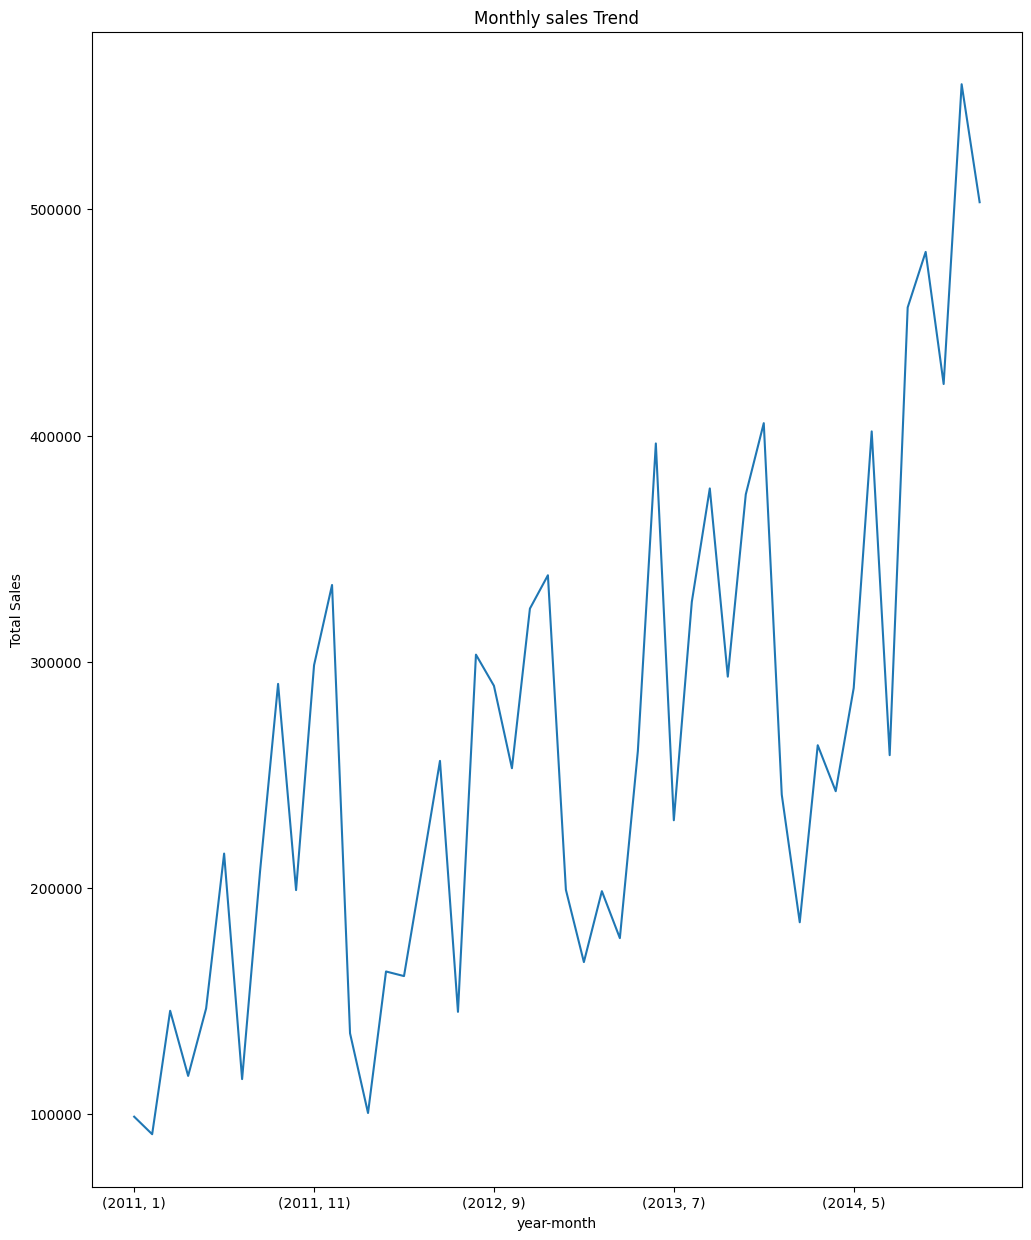

In [7]:
#visualize monthly sales trend
import matplotlib.pyplot as plt

monthly_sales.plot(figsize=(12,15))
plt.title("Monthly sales Trend")
plt.xlabel("year-month")
plt.ylabel("Total Sales")
plt.show()


In [11]:
#yearly sales analysis
df["year"]= df["Order.Date"].dt.year
 
yearly_sales = df.groupby("year")["Sales"].sum()
yearly_sales

year
2011    2259511
2012    2677493
2013    3405860
2014    4300041
Name: Sales, dtype: int64

In [13]:
growth_percentage = yearly_sales.pct_change()*100
print(growth_percentage.round(2).astype(str) + "%")

year
2011      nan%
2012     18.5%
2013     27.2%
2014    26.25%
Name: Sales, dtype: object


nan -No percentage for 2011 (first year has nothing to compare)


In [14]:
#If you want to remove nan% for first year:
growth_percentage = yearly_sales.pct_change() * 100

growth_percentage = growth_percentage.fillna(0)

print(growth_percentage.round(2).astype(str) + "%")

year
2011      0.0%
2012     18.5%
2013     27.2%
2014    26.25%
Name: Sales, dtype: object


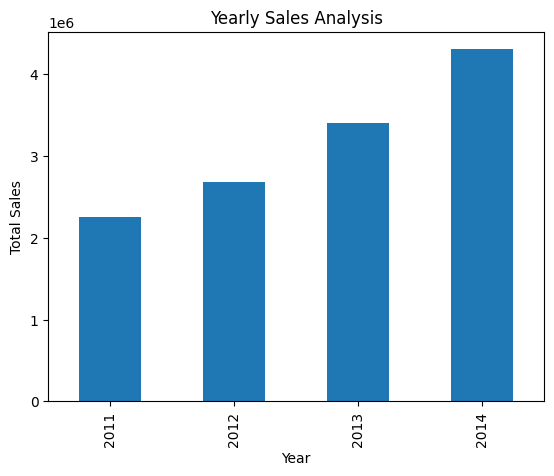

In [15]:
import matplotlib.pyplot as plt

yearly_sales.plot(kind="bar")
plt.title("Yearly Sales Analysis")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()

In [ ]:
monthly_sales.idxmax() #idxmax() → returns month with highest sales

(np.int32(2014), np.int32(11))

In [17]:
monthly_sales.max()

np.int64(555312)

In [21]:
monthly_sales.idxmin()


(np.int32(2011), np.int32(2))

In [22]:
monthly_sales.min()

np.int64(91152)

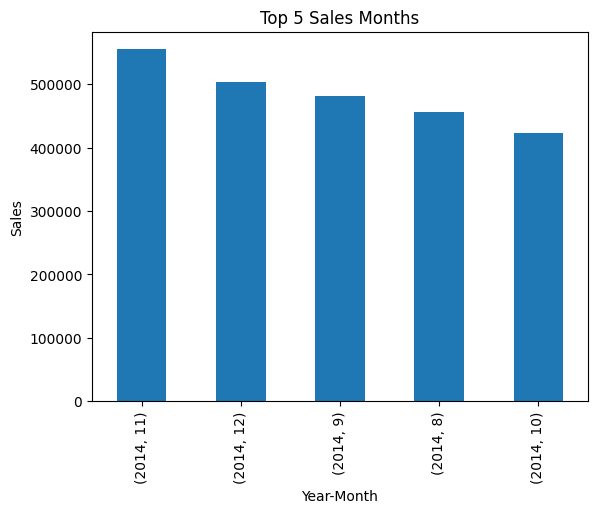

In [23]:
top_5_months = monthly_sales.sort_values(ascending=False).head(5)

top_5_months.plot(kind="bar")
plt.title("Top 5 Sales Months")
plt.xlabel("Year-Month")
plt.ylabel("Sales")
plt.show()

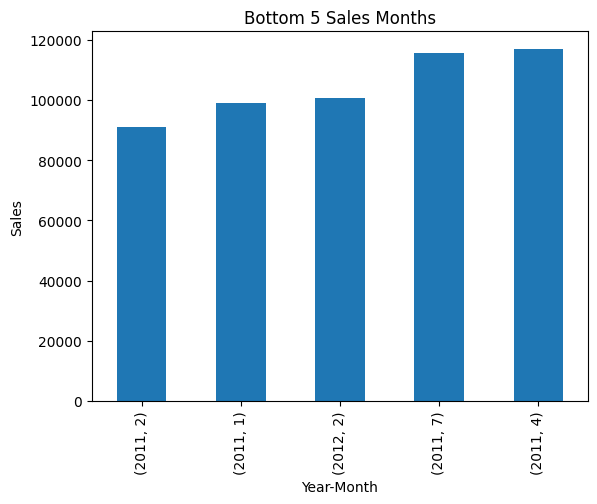

In [24]:
bottom_5_months = monthly_sales.sort_values().head(5)

bottom_5_months.plot(kind="bar")
plt.title("Bottom 5 Sales Months")
plt.xlabel("Year-Month")
plt.ylabel("Sales")
plt.show()

subtask 2
Which products sell the most?
Which products generate highest revenue?
Which categories perform best?
Which products are profitable?
Create graphs
Write insights

In [28]:
df.columns

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', '记录数', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID',
       'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum', 'Month', 'Day',
       'Day_Name', 'year', 'month'],
      dtype='object')

In [49]:
#Group sales by Product
product_sales = df.groupby("Product.Name")["Sales"].sum().sort_values(ascending= False)

product_sales

Product.Name
Apple Smart Phone, Full Size                                        86936
Cisco Smart Phone, Full Size                                        76441
Motorola Smart Phone, Full Size                                     73159
Nokia Smart Phone, Full Size                                        71904
Canon imageCLASS 2200 Advanced Copier                               61600
                                                                    ...  
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                      8
Grip Seal Envelopes                                                     7
Xerox 20                                                                6
Avery 5                                                                 6
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac        2
Name: Sales, Length: 3788, dtype: int64

In [40]:
#sales by category
category_sales =df.groupby("Category")["Sales"].sum().sort_values(ascending= False)
category_sales

Category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: Sales, dtype: int64

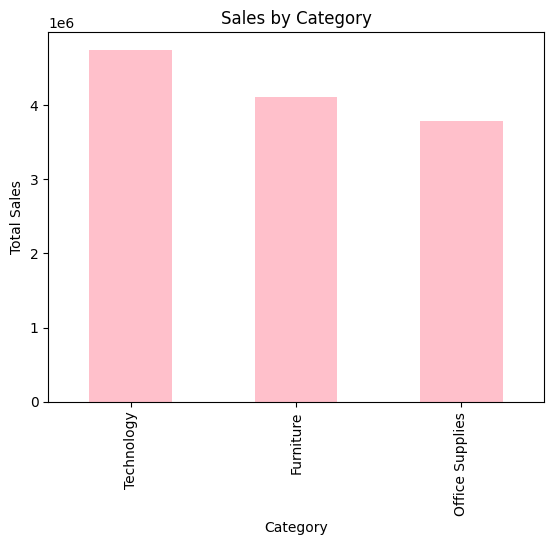

In [43]:
import matplotlib.pyplot as plt
category_sales.plot(kind = "bar",color="pink")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

In [53]:
product_profit = df.groupby("Product.Name")["Profit"].sum().sort_values(ascending=False)
product_profit.head(10)



Product.Name
Canon imageCLASS 2200 Advanced Copier                       25199.9280
Cisco Smart Phone, Full Size                                17238.5206
Motorola Smart Phone, Full Size                             17027.1130
Hoover Stove, Red                                           11807.9690
Sauder Classic Bookcase, Traditional                        10672.0730
Harbour Creations Executive Leather Armchair, Adjustable    10427.3260
Nokia Smart Phone, Full Size                                 9938.1955
Cisco Smart Phone, with Caller ID                            9786.6408
Nokia Smart Phone, with Caller ID                            9465.3257
Belkin Router, USB                                           8955.0180
Name: Profit, dtype: float64

#sub task 3

Which regions/cities/states generate highest sales?
Which locations generate lowest sales?
Which markets should business focus on?
Visualize geographic performance

In [62]:
df["State"].nunique() #This tells how many different states exist.


1094

In [63]:
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False)
state_sales.head(10)

State
England                   485166
California                457731
Ile-de-France             317818
New York                  310914
New South Wales           270509
Queensland                238311
North Rhine-Westphalia    216458
Texas                     170187
San Salvador              153648
National Capital          152185
Name: Sales, dtype: int64

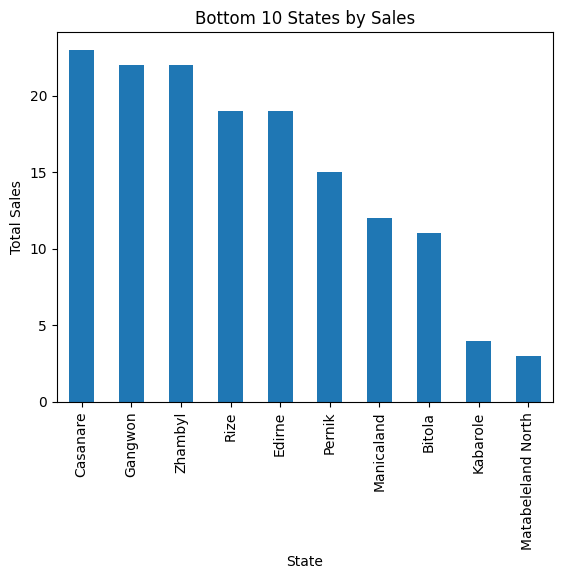

In [72]:
#low-performing states

state_sales.tail(10).plot(kind="bar")
plt.title("Bottom 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.show()

In [67]:
#City-wise sales analysis
city_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False)
city_sales.head(5)

City
New York City    256397
Los Angeles      175857
Manila           120896
Seattle          119552
San Francisco    112690
Name: Sales, dtype: int64

In [68]:
city_sales.tail(5)

City
Ormond Beach    3
Elyria          2
Jupiter         2
Pensacola       2
Abilene         1
Name: Sales, dtype: int64

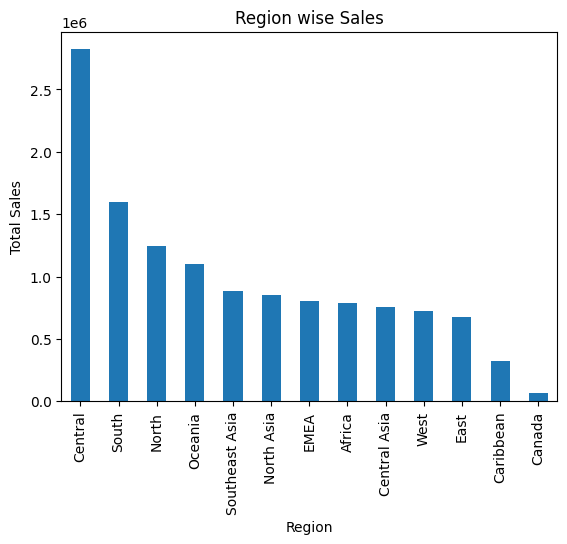

In [71]:
#region wise sales

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
region_sales
region_sales.plot(kind= "bar")
plt.title("Region wise Sales")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()


# Week 3 - RFM Customer Segmentation Analysis


In [19]:
import pandas as pd

df = pd.read_csv("final_cleaned_superstore.csv")
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum,Month,Day,Day_Name
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07,CA-2011-130813,...,Second Class,4.37,California,Paper,2011,North America,2,1,7,Friday
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21,CA-2011-148614,...,Standard Class,0.94,California,Paper,2011,North America,4,1,21,Friday
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05,CA-2011-118962,...,Standard Class,1.81,California,Paper,2011,North America,32,8,5,Friday
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05,CA-2011-118962,...,Standard Class,4.59,California,Paper,2011,North America,32,8,5,Friday
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29,CA-2011-146969,...,Standard Class,1.32,California,Paper,2011,North America,40,9,29,Thursday


In [78]:
df.columns

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', '记录数', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID',
       'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum', 'Month', 'Day',
       'Day_Name'],
      dtype='object')

In [4]:

df["Order.Date"]= pd.to_datetime(df["Order.Date"])

#Choose the Reference Date


To calculate Recency, we need a fixed date to compare customer purchases against.

Recency means:

“How many days ago did the customer last purchase”

So we need:

customer’s last order date
one fixed latest date

In [5]:
reference_date = df["Order.Date"].max() + pd.Timedelta(days =1) #Adds 1 extra day
reference_date

Timestamp('2015-01-01 00:00:00')

In [6]:
rfm = df.groupby("Customer.ID").agg({
    "Order.Date" :lambda x:(reference_date - x.max()).days,
    'Order.ID':"nunique",
    "Sales":"sum"

})

In [7]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [8]:
rfm.head(5)

,Recency,Frequency,Monetary
Customer.ID,,,
AA-103151,9,5,1445
AA-103152,14,7,6105
AA-103153,695,2,633
AA-103154,185,5,5565
AA-103751,7,4,2407


qcut() - helps to divide
labels = [5,4,3,2,1]) - reverse Order

Because:

smaller recency = better

lowest recency gets score 5
highest recency gets score 1

In [10]:
#recency_score
rfm["R_Score"] = pd.qcut(rfm['Recency'],5,labels = [5,4,3,2,1])

In [ ]:
#frequency score
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method = "first"),
                         5,labels=[1,2,3,4,5])


#frequency score

#rank(method='first') -

Sometimes many customers have same frequency.

Ranking avoids duplicate bin issues

In [20]:
rfm['M_score'] = pd.qcut(rfm['Monetary'],5,labels = [1,2,3,4,5])


In [21]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_score,M_score,RFM_Score
Customer.ID,,,,,,,
AA-103151,9,5,1445,5,3,3,533
AA-103152,14,7,6105,5,4,5,545
AA-103153,695,2,633,1,1,2,112
AA-103154,185,5,5565,2,3,5,235
AA-103751,7,4,2407,5,2,3,523


In [15]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

In [16]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_score,M_score,RFM_Score
Customer.ID,,,,,,,
AA-103151,9,5,1445,5,3,3,533
AA-103152,14,7,6105,5,4,5,545
AA-103153,695,2,633,1,1,2,112
AA-103154,185,5,5565,2,3,5,235
AA-103751,7,4,2407,5,2,3,523


In [30]:
def customer_segment(row):

    if row['R_Score'] >= 4 and row['F_score'] >= 4 and row['M_score'] >= 4:
        return 'High Value Customer'

    elif row['F_score'] >= 4:
        return 'Loyal Customer'

    elif row['R_Score'] <= 2:
        return 'At Risk Customer'

    elif row['R_Score'] == 1 and row['F_score'] == 1:
        return 'Lost Customer'

    else:
        return 'Other Customers'

In [31]:
rfm['Customer_Segment'] = rfm.apply(customer_segment, axis=1)

In [32]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_score,M_score,RFM_Score,Customer_Segment
Customer.ID,,,,,,,,
AA-103151,9,5,1445,5,3,3,533,Other Customers
AA-103152,14,7,6105,5,4,5,545,High Value Customer
AA-103153,695,2,633,1,1,2,112,At Risk Customer
AA-103154,185,5,5565,2,3,5,235,At Risk Customer
AA-103751,7,4,2407,5,2,3,523,Other Customers


Customer_Segment
At Risk Customer       1543
Other Customers        1381
Loyal Customer         1152
High Value Customer     797
Name: count, dtype: int64


<Axes: xlabel='Customer_Segment'>

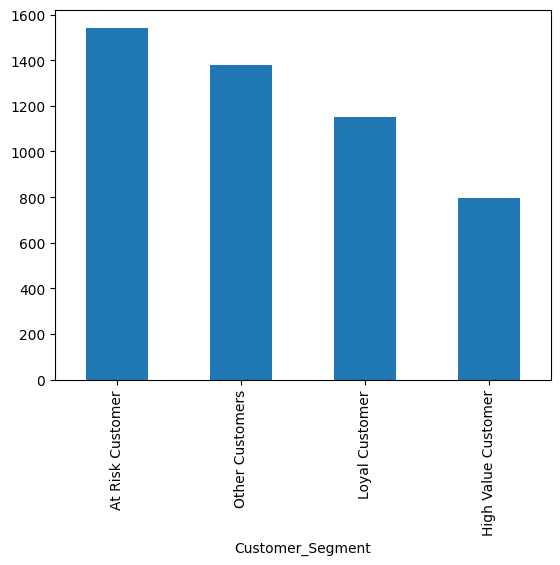

In [34]:
segment_counts = rfm['Customer_Segment'].value_counts()

print(segment_counts)
segment_counts.plot(kind='bar')

In [36]:
#Segmentation Function
def customer_segment(row):

    if row['R_Score'] >= 4 and row['F_score'] >= 4 and row['M_score'] >= 4:
        return 'High Value Customer'

    elif row['F_score'] >= 4 and row['M_score'] >= 3:
        return 'Loyal Customer'

    elif row['R_Score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk Customer'

    elif row['R_Score'] >= 4 and row['F_score'] <= 2:
        return 'New Customer'

    elif row['R_Score'] == 1 and row['F_score'] == 1:
        return 'Lost Customer'

    elif row['R_Score'] >= 3 and row['F_score'] >= 3:
        return 'Potential Loyalist'

    else:
        return 'Other Customers'

In [37]:
rfm['Customer_Segment'] = rfm.apply(customer_segment, axis=1)

In [38]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_score,M_score,RFM_Score,Customer_Segment
Customer.ID,,,,,,,,
AA-103151,9,5,1445,5,3,3,533,Potential Loyalist
AA-103152,14,7,6105,5,4,5,545,High Value Customer
AA-103153,695,2,633,1,1,2,112,Lost Customer
AA-103154,185,5,5565,2,3,5,235,At Risk Customer
AA-103751,7,4,2407,5,2,3,523,New Customer


In [40]:
segment_counts = rfm['Customer_Segment'].value_counts()

print(segment_counts)

Customer_Segment
Other Customers        1002
Loyal Customer          986
High Value Customer     797
Potential Loyalist      773
Lost Customer           503
New Customer            444
At Risk Customer        368
Name: count, dtype: int64


<Axes: title={'center': 'Customer Segments Distribution'}, xlabel='Customer_Segment'>

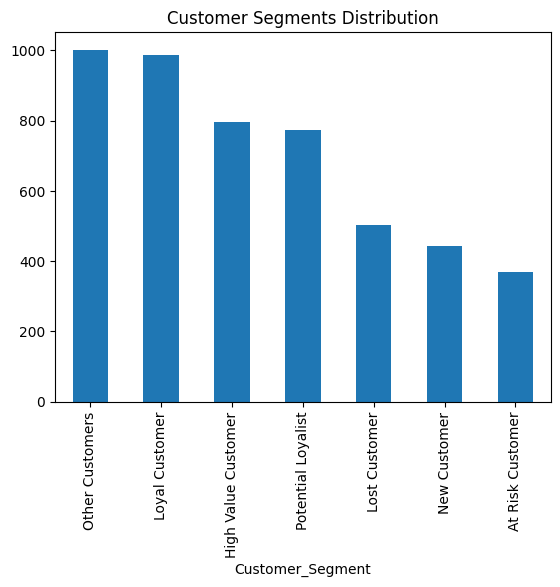

In [42]:
segment_counts.plot(kind='bar', title='Customer Segments Distribution')

<Axes: ylabel='count'>

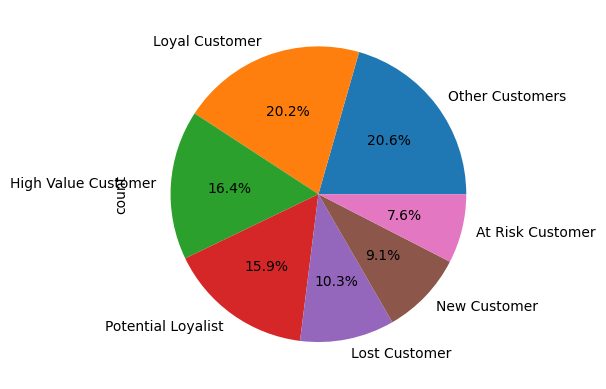

In [43]:
segment_counts.plot(kind='pie', autopct='%1.1f%%')

<Axes: title={'center': 'Frequency vs Monetary'}, xlabel='Frequency', ylabel='Monetary'>

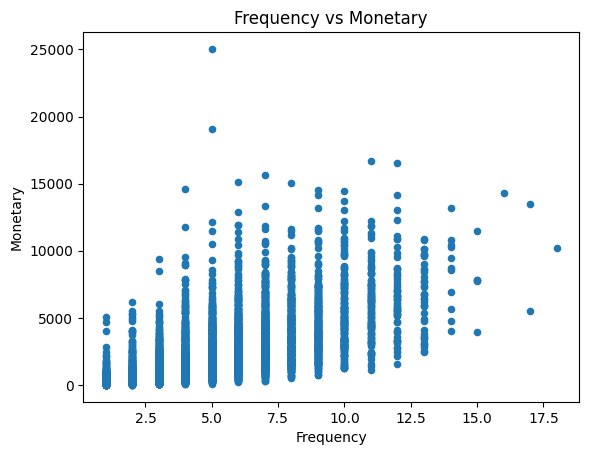

In [48]:
rfm.plot.scatter(
    x='Frequency',
    y='Monetary',
    title='Frequency vs Monetary'
)

In [52]:
heatmap_data = rfm.pivot_table(
    index='R_Score',
    columns='F_score',
    values='Monetary',
    aggfunc='mean'
)

C:\Users\Manasa\AppData\Local\Temp\ipykernel_28248\3196079759.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = rfm.pivot_table(


In [55]:
import seaborn as sns

C:\Users\Manasa\AppData\Local\Temp\ipykernel_28248\222043726.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = rfm.pivot_table(


<Axes: xlabel='F_score', ylabel='R_Score'>

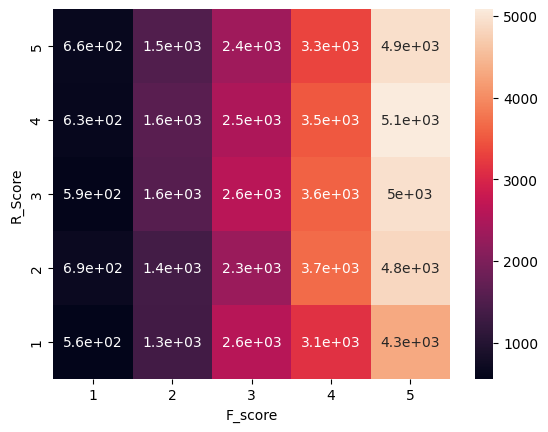

In [57]:
heatmap_data = rfm.pivot_table(
    index='R_Score',
    columns='F_score',
    values='Monetary',
    aggfunc='mean'
)

sns.heatmap(heatmap_data, annot=True)